## **Notebook 2: Exploratory Data Analysis**

### **1- Introduction**
---

This notebook presents an in-depth exploratory analysis of Airbnb listings in Berlin, uncovering insights valuable to hosts, potential guests, and the platform itself. It examines a range of questions, from overall pricing trends and neighbourhood comparisons to the influence of amenities and host attributes on listing performance. Through these analyses, the main aim is to understand price patterns across the city, explore relationships between key variables (such as price, availability, and reviews), and identify any data quirks or quality issues that could affect interpretation. Ultimately, the findings will inform pricing strategies, guide travelers’ expectations, and highlight areas of opportunity in Berlin’s rental market.

### **2- Data Overview**
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
from folium.features import DivIcon
from matplotlib import cm, colors
from adjustText import adjust_text
from wordcloud import WordCloud

%matplotlib inline

In [2]:
# Load cleaned data
df = pd.read_csv('../data/listings_cleaned.csv')

# Quick preview
df.head()

,price,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,room_type,availability_30,host_is_superhost,host_since,number_of_reviews,review_scores_rating,amenities,host_experience_years,amenities_list,amenities_count
0,105.0,Prenzlauer Berg Südwest,Pankow,52.53471,13.41810,Entire home/apt,0,f,2008-10-19,149,4.63,"[""Bathtub"", ""Dishes and silverware"", ""Bed line...",16.726027,"['bathtub', 'dishes and silverware', 'bed line...",44
1,135.0,Prenzlauer Berg Südwest,Pankow,52.53269,13.41805,Entire home/apt,0,f,2009-08-25,7,5.00,"[""Bathtub"", ""Dryer"", ""Dishes and silverware"", ...",15.876712,"['bathtub', 'dryer', 'dishes and silverware', ...",32
2,75.0,Prenzlauer Berg Nordwest,Pankow,52.54813,13.40366,Entire home/apt,0,t,2009-11-18,26,4.68,"[""Heating"", ""Host greets you"", ""Smoke alarm"", ...",15.643836,"['heating', 'host greets you', 'smoke alarm', ...",14
3,77.0,nördliche Luisenstadt,Friedrichshain-Kreuzberg,52.50312,13.43508,Entire home/apt,0,f,2009-12-20,48,4.72,"[""Heating"", ""Room-darkening shades"", ""Children...",15.556164,"['heating', 'room-darkening shades', 'children...",17
4,40.0,Reuterstraße,Neukölln,52.49419,13.42166,Entire home/apt,0,f,2010-01-08,299,4.77,"[""Dishes and silverware"", ""Luggage dropoff all...",15.504110,"['dishes and silverware', 'luggage dropoff all...",19


In [3]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8898 entries, 0 to 8897
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   price                         8898 non-null   float64
 1   neighbourhood_cleansed        8898 non-null   object 
 2   neighbourhood_group_cleansed  8898 non-null   object 
 3   latitude                      8898 non-null   float64
 4   longitude                     8898 non-null   float64
 5   room_type                     8898 non-null   object 
 6   availability_30               8898 non-null   int64  
 7   host_is_superhost             8898 non-null   object 
 8   host_since                    8879 non-null   object 
 9   number_of_reviews             8898 non-null   int64  
 10  review_scores_rating          8898 non-null   float64
 11  amenities                     8898 non-null   object 
 12  host_experience_years         8898 non-null   float64
 13  ame

In [4]:
# Display summary stats
df.describe()

,price,latitude,longitude,availability_30,number_of_reviews,review_scores_rating,host_experience_years,amenities_count
count,8898.000000,8898.000000,8898.000000,8898.000000,8898.000000,8898.000000,8898.000000,8898.000000
mean,128.763880,52.508612,13.400270,14.052034,57.609238,4.775239,7.685339,30.727242
std,316.080704,0.035009,0.072829,11.070817,114.269752,0.316378,4.069817,15.025971
min,9.000000,52.340190,13.118150,0.000000,0.000000,0.000000,0.000000,1.000000
25%,65.000000,52.490870,13.354858,3.000000,1.000000,4.740000,3.836301,20.000000
50%,94.000000,52.509577,13.406136,13.000000,13.000000,4.850000,8.126027,30.000000
75%,138.000000,52.531488,13.436674,25.000000,62.000000,4.930000,11.043836,41.000000
max,10006.000000,52.650760,13.721390,30.000000,2859.000000,5.000000,16.923288,94.000000


**About dataset:** The current dataset comprises 8,898 Airbnb listings in Berlin, including each listing’s nightly price, location (neighbourhood and district), room type, availability, host status, review counts and scores, and amenities. Some preprocessing steps were already done in the data cleaning and wrangling process to enrich the dataset (e.g. computing each host’s experience in years from the host’s join date, and parsing the list of amenities for each listing). The resulting dataset is largely complete; only a handful of entries have missing values in the host_since field, which we will not use directly in EDA.

Key numeric fields and their summary statistics are:

- **Price:** Ranges from €9 to an outlier of €10,006 per night. The median price is €94, and the mean is €129, indicating a right-skewed distribution with a few very high-priced listings pulling the average up.
- **Availability (next 30 days):** Median availability is 13 days, but some listings are fully booked (0 days available), while others are entirely free (30 days available).
- **Number of Reviews:** Most listings have at least a few reviews (median 13 reviews), though some others have 0 reviews. The most reviewed properties have over 60 reviews, indicating popular stays.
- **Review Score:** The average rating is around 4.78 out of 5, indicating many hosts maintain high ratings. A small number of listings have 0 rating.
- **Amenities:** Listings offer a wide range of amenities. On average, a listing has 30 amenities. Some offer as few as 1, while others provide more than 50 amenities.

### **3- Business Questions and Analyses**
---

#### **Q1. What is the overall price landscape of Airbnb listings in Berlin?**

Understanding the pricing landscape is essential for shaping effective pricing strategies on Airbnb. This baseline analysis identifies typical price ranges and flags outliers, helping hosts to set competitive rates, and giving guests realistic expectations based on their budget. It also lays the foundation for deeper exploration into how location, amenities, and host attributes influence pricing. So, these insights ultimately support data-driven decisions for pricing optimization, guest targeting, and host strategy across Berlin.

In [5]:
df['price'].describe(percentiles=[.25, .5, .75, .95, .99])

count     8898.000000
mean       128.763880
std        316.080704
min          9.000000
25%         65.000000
50%         94.000000
75%        138.000000
95%        270.000000
99%        539.090000
max      10006.000000
Name: price, dtype: float64

- The median price is €94, while the mean is higher at €129, indicating the presence of high-priced properties.
- Most listings are priced between €65 and €138 per night (interquartile range).
- A small number of listings exceed €530 per night, with the maximum recorded at over €10,000 —these are likely luxury properties or potential data entry errors.
- Overall, the majority of Berlin Airbnb options fall within a moderate price range, but the average is pulled up by a few extremely expensive listings.

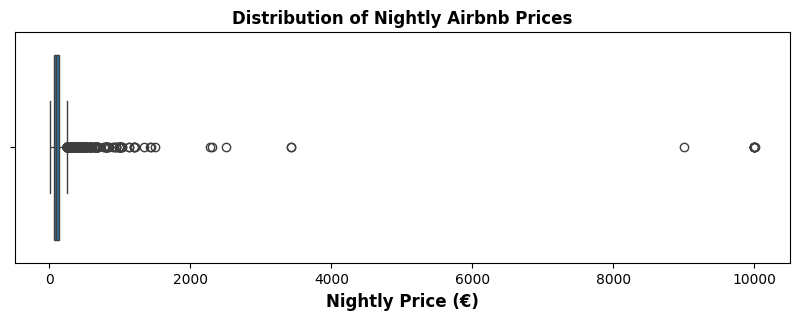

In [6]:
plt.figure(figsize=(10, 3))

sns.boxplot(x=df['price'])
plt.title('Distribution of Nightly Airbnb Prices', fontsize=12, fontweight='bold')
plt.xlabel('Nightly Price (€)', fontsize=12, fontweight='bold')

plt.show()

The boxplot clearly reveals extreme pricing outliers on the high end, which compresses the visualization of typical values. Most listings are clustered at lower prices, while a small number of very expensive listings stretch the scale. So, **we expect the nightly price distribution of the listings to be strongly right-skewed.**

But first let's identify how many listings lie above the 99th percentile: 


In [7]:
# Number of listings with price above the 99th percentile (outliers)
price_99th_percentile = df['price'].quantile(0.99)
outliers = df[df['price'] > price_99th_percentile]
n_above_99th = outliers.shape[0]
print(f"Total number of outlier listings with nightly prices above the 99th percentile (€{price_99th_percentile:.2f}): {n_above_99th}")

Total number of outlier listings with nightly prices above the 99th percentile (€539.09): 89


We have 89 listings exceed the 99th percentile, ranging from €539 to €10,000. Such properties are exceptional and not representative of the market. 

**To provide a more representative view of the price landscape and enable clearer visual interpretation, we cap all metrices at the 99th percentile.** Unless other specified, the subsequent analyses and visualizations in this notebook will be based on this trimmed dataset (*df_zoomed*) to ensure that our insights are not skewed by a handful of ultra high-priced listings and instead accurately reflect typical pricing patterns in the Berlin Airbnb market.

In [8]:
# Filter dataset to exclude extreme outliers by keeping only listings priced up to the 99th percentile
df_zoomed = df[df['price'] <= price_99th_percentile].copy()

print(f"Number of listings after zooming in on the 99th percentile: {df_zoomed.shape[0]}")

Number of listings after zooming in on the 99th percentile: 8809


In [9]:
df_zoomed['price'].describe()

count    8809.000000
mean      112.139743
std        71.305708
min         9.000000
25%        65.000000
50%        93.000000
75%       136.000000
max       539.000000
Name: price, dtype: float64

**After excluding the top 1% of outliers, both the mean and median nightly prices decreased—from €129 to €112 (for mean) and from €94 to €93 (for median). With these extreme values removed, the average price now provides a more accurate reflection of the typical listing in the dataset.**

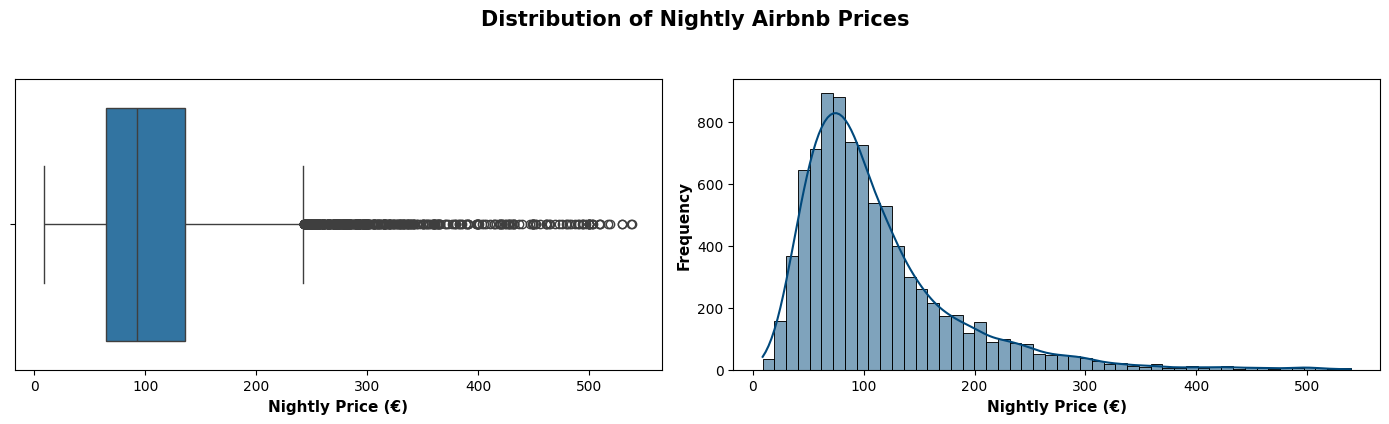

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [1, 1]})

sns.boxplot(x=df_zoomed['price'], ax=axes[0], color='#1f77b4')
axes[0].set_xlabel('Nightly Price (€)', fontsize=11, fontweight='bold')

sns.histplot(df_zoomed['price'], bins=50, kde=True, ax=axes[1], color="#00487B")
axes[1].set_xlabel('Nightly Price (€)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')

fig.suptitle('Distribution of Nightly Airbnb Prices', fontsize=15, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

By zooming in on the prices, the boxplot and histogram above show that **Berlin’s Airbnb market operates in a moderate price range with most nightly rates under €150. Budget options below €50 exist but are less common, while ultra-premium rentals above €500 are very rare. This right-skewed price landscape suggests that while travelers can generally find affordable accommodations, there is a niche high-end market.** Hosts should note that typical travelers have many choices in the mid-range, and only few can command very high prices.

#### **Q2. How do nightly prices vary across Berlin’s main districts?**

Berlin is divided into 12 main districts, and location is a key factor in pricing. Here we analyze nightly Airbnb rates across these districts in order to uncover spatial pricing patterns that help hosts benchmark listings, guide guests toward budget-friendly areas, and support Airbnb in tailoring district-level pricing strategies and local promotions.

In [11]:
# Calculate summary stats for nightly price by district
# Median, average (mean), and number of listings per district
district_stats = (
    df_zoomed
    .groupby('neighbourhood_group_cleansed')['price']
    .agg(['median', 'mean', 'count'])
    .sort_values(by='median', ascending=False)
    .reset_index()
    .rename(columns={
        'neighbourhood_group_cleansed': 'District',
        'median': 'Median Price (€)',
        'mean': 'Average Price (€)',
        'count': 'Number of Listings'
    })
)
district_stats

,District,Median Price (€),Average Price (€),Number of Listings
0,Mitte,110.0,131.029276,1947
1,Friedrichshain-Kreuzberg,96.0,111.460989,1820
2,Pankow,95.0,112.912281,1311
3,Charlottenburg-Wilm.,91.0,112.170253,1069
4,Lichtenberg,86.5,102.866412,262
5,Neukölln,85.0,101.649123,741
6,Tempelhof - Schöneberg,85.0,101.276083,623
7,Treptow - Köpenick,82.0,96.489461,427
8,Steglitz - Zehlendorf,80.0,93.267176,262
9,Spandau,78.0,96.619469,113


In [12]:
# Define the order of districts based on median prices
district_price_order = district_stats['District'].tolist()
district_price_order

['Mitte',
 'Friedrichshain-Kreuzberg',
 'Pankow',
 'Charlottenburg-Wilm.',
 'Lichtenberg',
 'Neukölln',
 'Tempelhof - Schöneberg',
 'Treptow - Köpenick',
 'Steglitz - Zehlendorf',
 'Spandau',
 'Marzahn - Hellersdorf',
 'Reinickendorf']

/var/folders/28/k8yvfv954hj1rd6zldbm4_dw0000gn/T/ipykernel_26290/1803595024.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price', y='neighbourhood_group_cleansed',


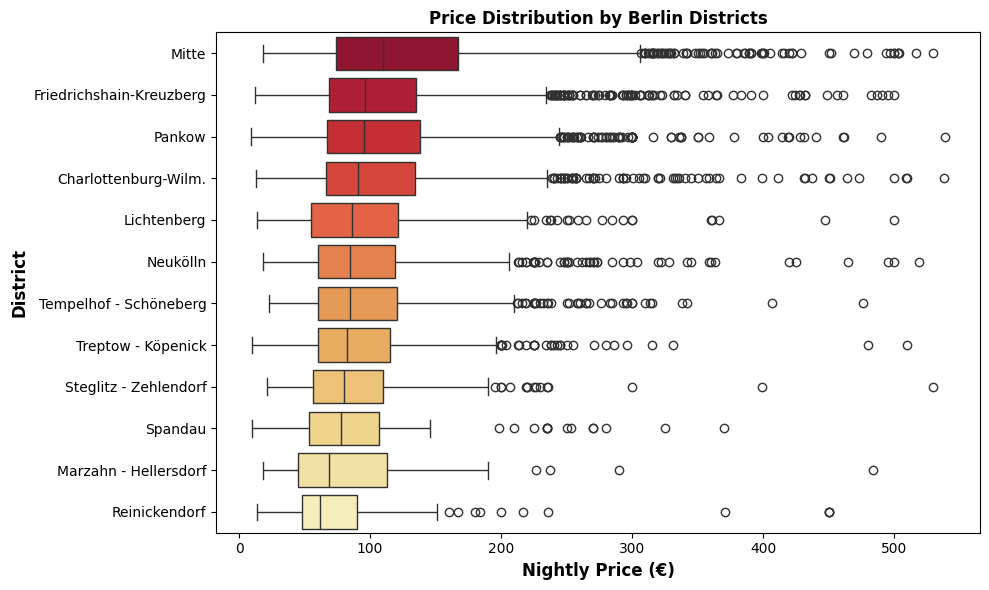

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(x='price', y='neighbourhood_group_cleansed',
            data=df_zoomed, order=district_price_order, palette='YlOrRd_r')
plt.title('Price Distribution by Berlin Districts', fontsize=12, fontweight='bold')
plt.xlabel('Nightly Price (€)', fontsize=12, fontweight='bold')
plt.ylabel('District', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


**Location within Berlin greatly impacts price.**
- **Central Districts Cost More:** **Districts in the city center tend to command higher prices.** Mitte has the highest median price at about €110 per night, followed by Friedrichshain-Kreuzberg (€96), Pankow (€95), and Charlottenburg-Wilmersdorf (€91). These areas include popular neighbourhoods known for tourism, nightlife, and business centers, which drives up demand and prices.
- **Affordable Outer Districts:** **More peripheral districts are notably cheaper.** Reinickendorf has the lowest median price (€62), and other outer districts like Marzahn-Hellersdorf (median €69), Spandau (€78), Steglitz-Zehlendorf (€80), and Neukölln (€85) all have median prices under €90. These areas are relatively farther from the city’s main attractions, so nightly rates are generally lower.
- **Price Ranges and Outliers:** **Within each district, most listings still cluster in a moderate range (e.g. €50–€150). However, even the cheaper districts have a few higher-end listings.** Conversely, expensive districts like Mitte also offer a range of options including some budget-friendly listings, though their overall price level is higher.
- **Number of Listings:** **Supply is not uniform. Central districts not only charge more but also host far more listings.** Mitte and Friedrichshain-Kreuzberg each have well over 1,800 listings in the dataset, whereas outer districts like Marzahn-Hellersdorf or Reinickendorf have under 150 listings. This reflects how tourist demand (and likely Airbnb supply) is concentrated in central areas.

Let's drill down into the average Airbnb prices for individual neighbourhoods within each district:

#### **Q3. How do prices compare among neighbourhoods within each district?**

After understanding Berlin’s overall and district-level pricing, we now zoom into individual neighbourhoods to uncover micro-level trends. This helps identify premium areas or overlooked value pockets within each district. For hosts, it enables more precise pricing and strategic listing decisions. For guests, it reveals affordable or unique neighbourhoods. For Airbnb, these insights refine pricing models and improve location-based recommendations.


In [14]:
# Calculate summary price stats at the neighbourhood level within each district
# Groups by both 'District' and 'Neighbourhood'
# Median, mean, and number of listings for each neighbourhood
neigh_stats = (
    df_zoomed.groupby(['neighbourhood_group_cleansed', 'neighbourhood_cleansed'])['price']
    .agg(['median', 'mean', 'count']).reset_index()
    .rename(columns={'neighbourhood_group_cleansed': 'District', 
                     'neighbourhood_cleansed': 'Neighbourhood', 
                     'median': 'Median Price (€)',
                     'mean': 'Average Price (€)',
                     'count': 'Number of Listings'}))
neigh_stats

,District,Neighbourhood,Median Price (€),Average Price (€),Number of Listings
0,Charlottenburg-Wilm.,Barstraße,81.0,107.600000,35
1,Charlottenburg-Wilm.,Charlottenburg Nord,52.0,53.285714,7
2,Charlottenburg-Wilm.,Düsseldorfer Straße,98.5,112.927711,166
3,Charlottenburg-Wilm.,Forst Grunewald,171.0,157.200000,5
4,Charlottenburg-Wilm.,Grunewald,106.0,106.888889,54
...,...,...,...,...,...
133,Treptow - Köpenick,Niederschöneweide,88.0,104.695652,23
134,Treptow - Köpenick,Oberschöneweide,77.0,85.890909,55
135,Treptow - Köpenick,Plänterwald,84.0,107.333333,27
136,Treptow - Köpenick,Rahnsdorf/Hessenwinkel,94.0,100.440000,25


In [15]:
# Sort first by districts (A-Z), then by median price (as descending within district)
neigh_stats = neigh_stats.sort_values(
    by=['District', 'Median Price (€)'],
    ascending=[True, False]
).reset_index(drop=True)

neigh_stats

,District,Neighbourhood,Median Price (€),Average Price (€),Number of Listings
0,Charlottenburg-Wilm.,Forst Grunewald,171.0,157.200000,5
1,Charlottenburg-Wilm.,Wiesbadener Straße,116.0,103.461538,26
2,Charlottenburg-Wilm.,Schmargendorf,114.5,149.266667,30
3,Charlottenburg-Wilm.,Grunewald,106.0,106.888889,54
4,Charlottenburg-Wilm.,Heerstrasse,101.0,148.545455,22
...,...,...,...,...,...
133,Treptow - Köpenick,Kölln. Vorstadt/Spindlersf.,65.5,117.250000,12
134,Treptow - Köpenick,Johannisthal,65.0,72.680000,25
135,Treptow - Köpenick,Altglienicke,60.0,84.000000,18
136,Treptow - Köpenick,Baumschulenweg,55.5,79.687500,16


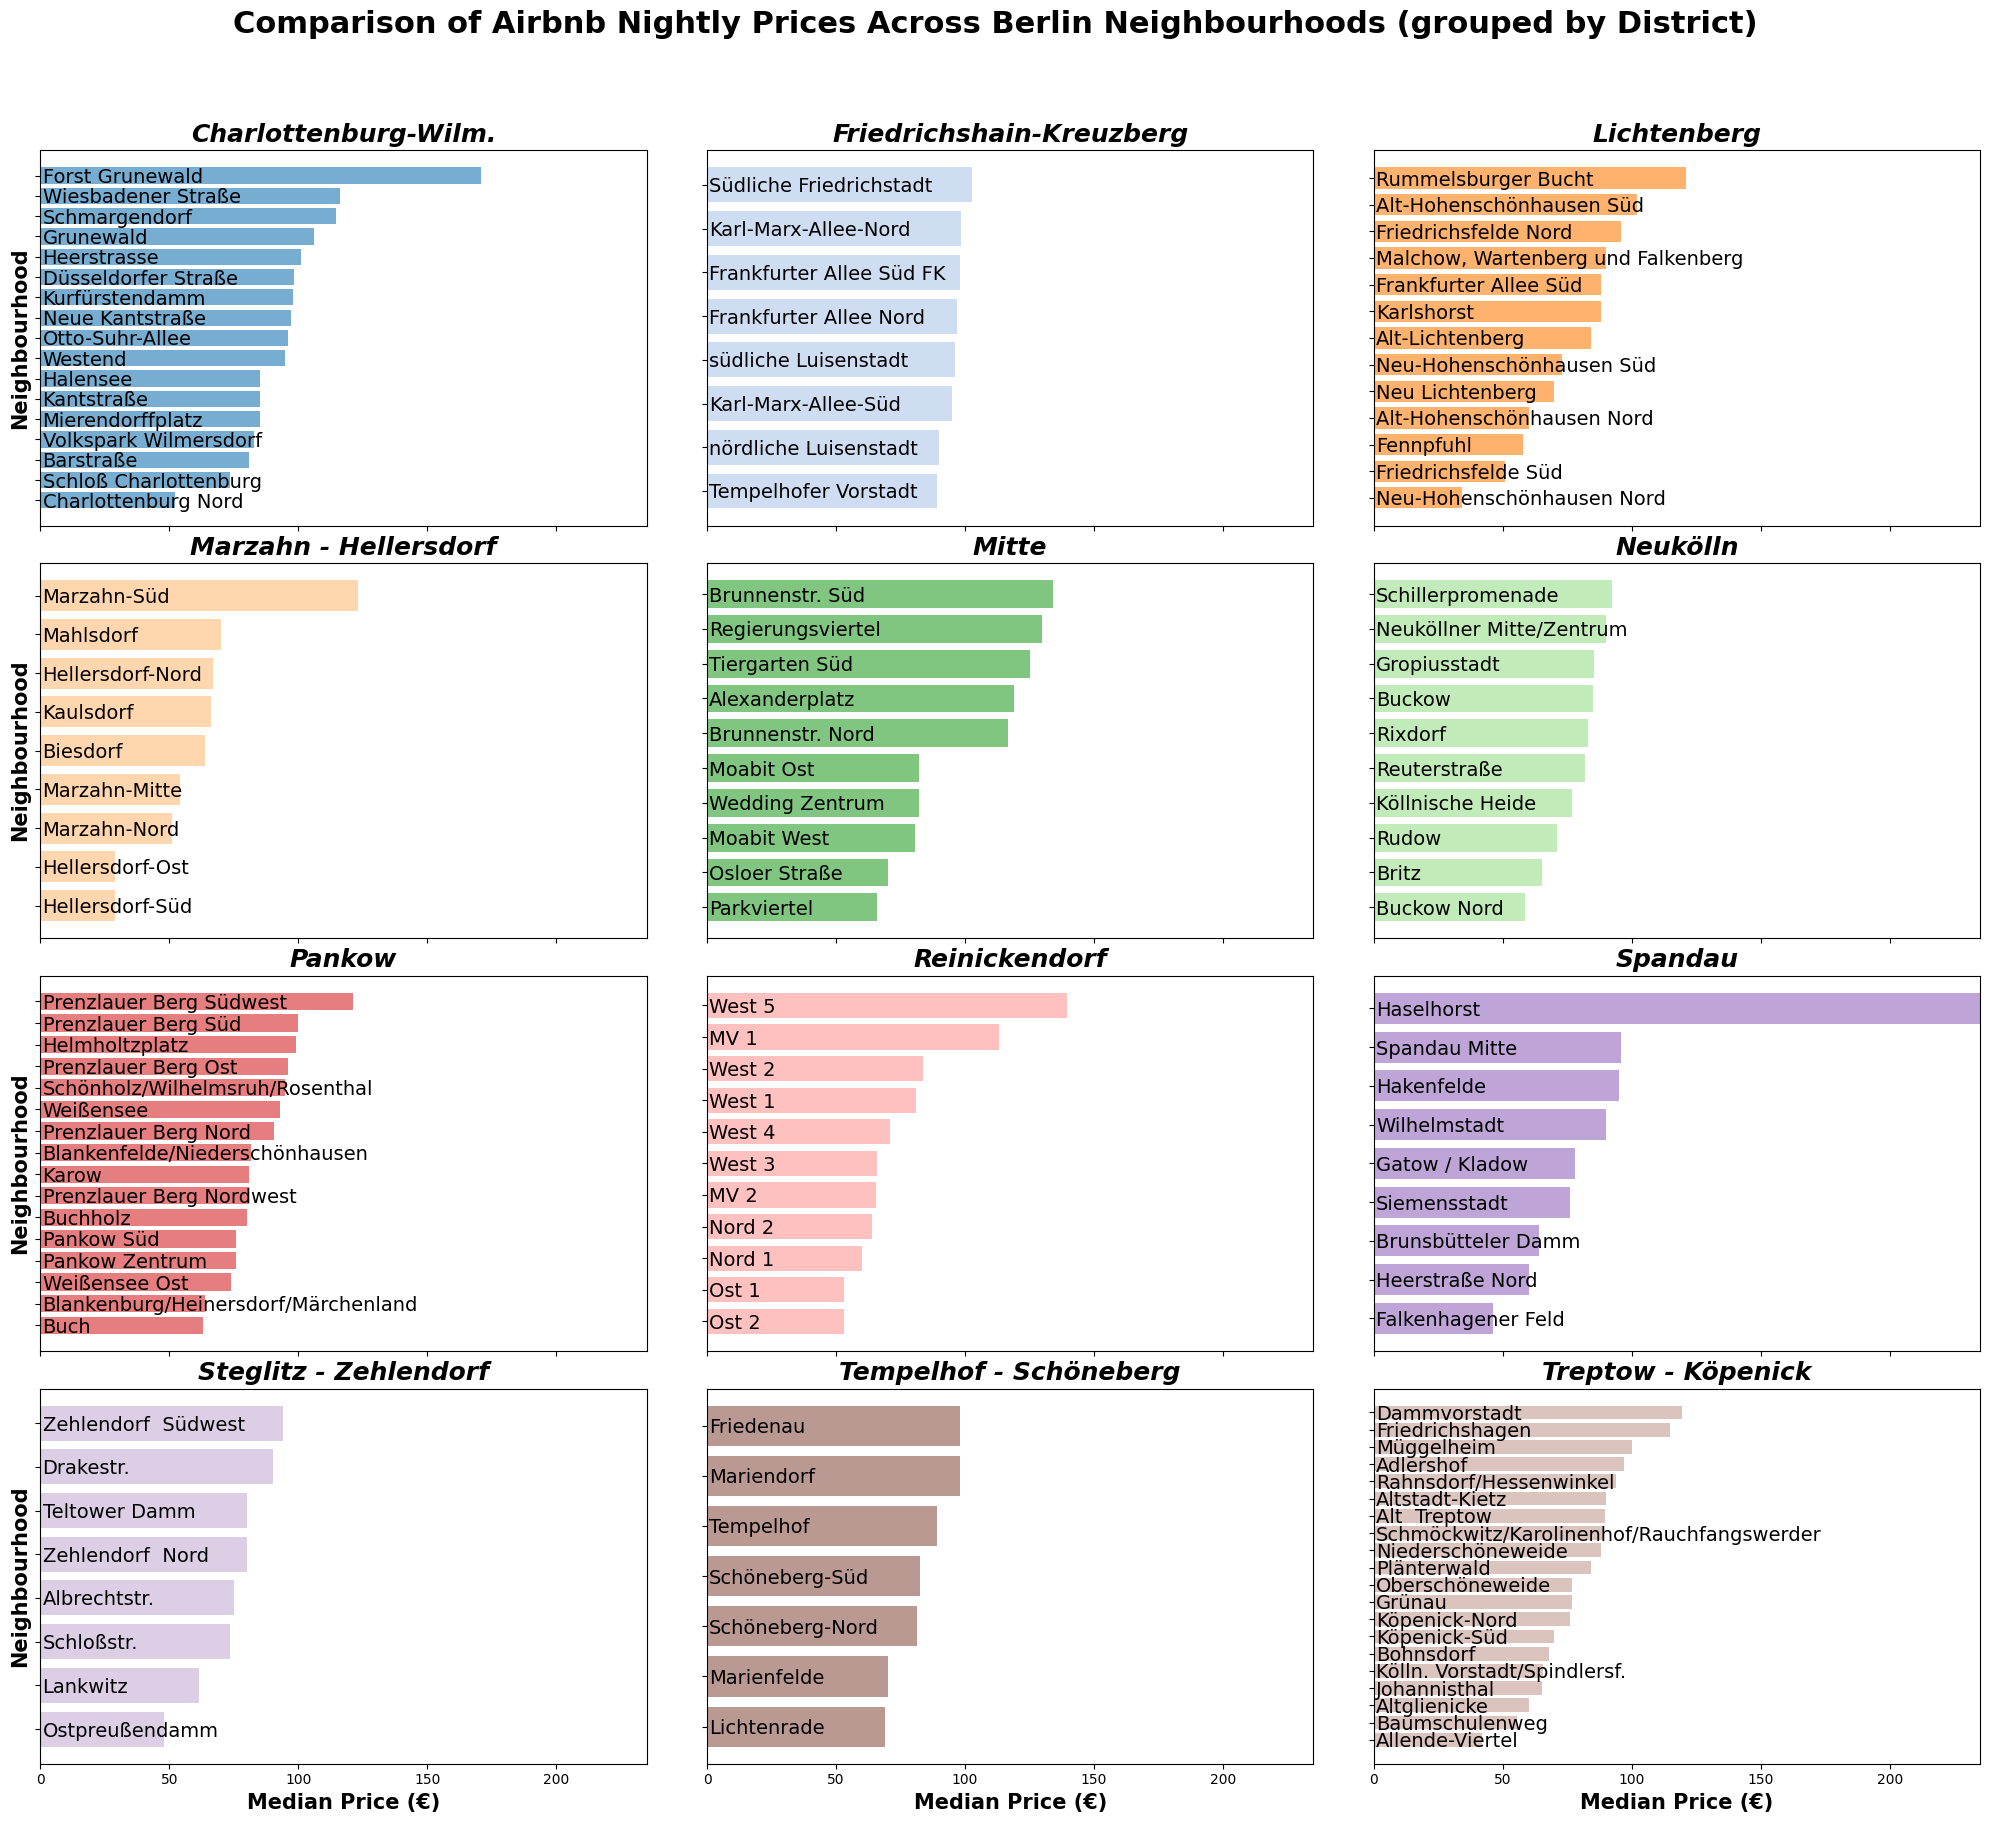

In [16]:
districts = neigh_stats['District'].unique()
colors = list(plt.cm.tab20.colors)

# Mapping from district to color as a dictionary
district_color_map = {district: colors[i % len(colors)] for i, district in enumerate(districts)}

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 18), sharex=True)
axes = axes.flatten()
max_price = neigh_stats['Median Price (€)'].max()

for i, district in enumerate(districts):
    data = neigh_stats[neigh_stats['District'] == district].sort_values('Median Price (€)', ascending=False)
    axes[i].barh(data['Neighbourhood'], data['Median Price (€)'], color=district_color_map[district], alpha=0.6)
    axes[i].set_title(district, fontsize=18, fontweight='bold', fontstyle='italic')
    axes[i].invert_yaxis()
    axes[i].set_xlim(0, max_price)
    if i in (0, 3, 6, 9):
        axes[i].set_ylabel("Neighbourhood", fontsize=15, fontweight='bold')
    if i in (9, 10, 11):
        axes[i].set_xlabel("Median Price (€)", fontsize=15, fontweight='bold')

for ax in axes:
    for label in ax.get_yticklabels():
        label.set_horizontalalignment('left')
        label.set_fontsize(14)
    ax.tick_params(axis='y', pad=-5)

fig.suptitle("Comparison of Airbnb Nightly Prices Across Berlin Neighbourhoods (grouped by District)", fontsize=22, fontweight='bold',  y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.subplots_adjust(wspace=0.1, hspace=0.1)  
plt.show()

The plot above breaks down the median nightly price of Airbnb listings at the neighbourhood level. This detailed view uncovers price diversity within districts, highlighting micro-market trends that broader district-level analysis might miss.

- **Substantial variation exists both within and across districts.** While districts like Charlottenburg-Wilmersdorf and Mitte generally have higher prices, there is still significant variations persisting within some districts. For example, Haselhorst stands out as the most expensive in Spandau.
- **Most affordable districts, such as Marzahn-Hellersdorf, Steglitz-Zehlendorf, Tempelhof-Schöneberg, are dominated by neighbourhoods with lower median prices.** 
- **Neighbourhoods with higher prices (e.g., Haselhorst in Spandau) may indicate localized demand or distinctive property characteristics within districts.**
- **Central, tourist-focused districts, such as Mitte and Friedrichshain-Kreuzberg, generally have higher and more uniform prices**, likely reflecting proximity to major attractions, nightlife, and business centers.

This granular breakdown empowers both potential hosts and guests to understand how pricing varies not only by location but also by local competition and neighbourhood dynamics. **Hosts in a typically low-cost district could still charge premium rates if their property is in a local hotspot, whereas hosts in expensive districts should be aware of more affordable pockets nearby that might compete on price.**

Let's have a closer look which neighbourhoods command the highest prices and which offer the best deals:

#### **Q4. Which individual neighbourhoods are the most expensive or most affordable?**


In [17]:
ind_neigh_prices = df_zoomed.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False)

print(f'Total unique number of neighbourhoods in the listings: {ind_neigh_prices.index.value_counts().shape[0]}')

Total unique number of neighbourhoods in the listings: 138


As it is hard to visualize 138 neighbourhoods at once, let's focus on the top 10 most expensive and the top 10 most affordable neighbourhoods.

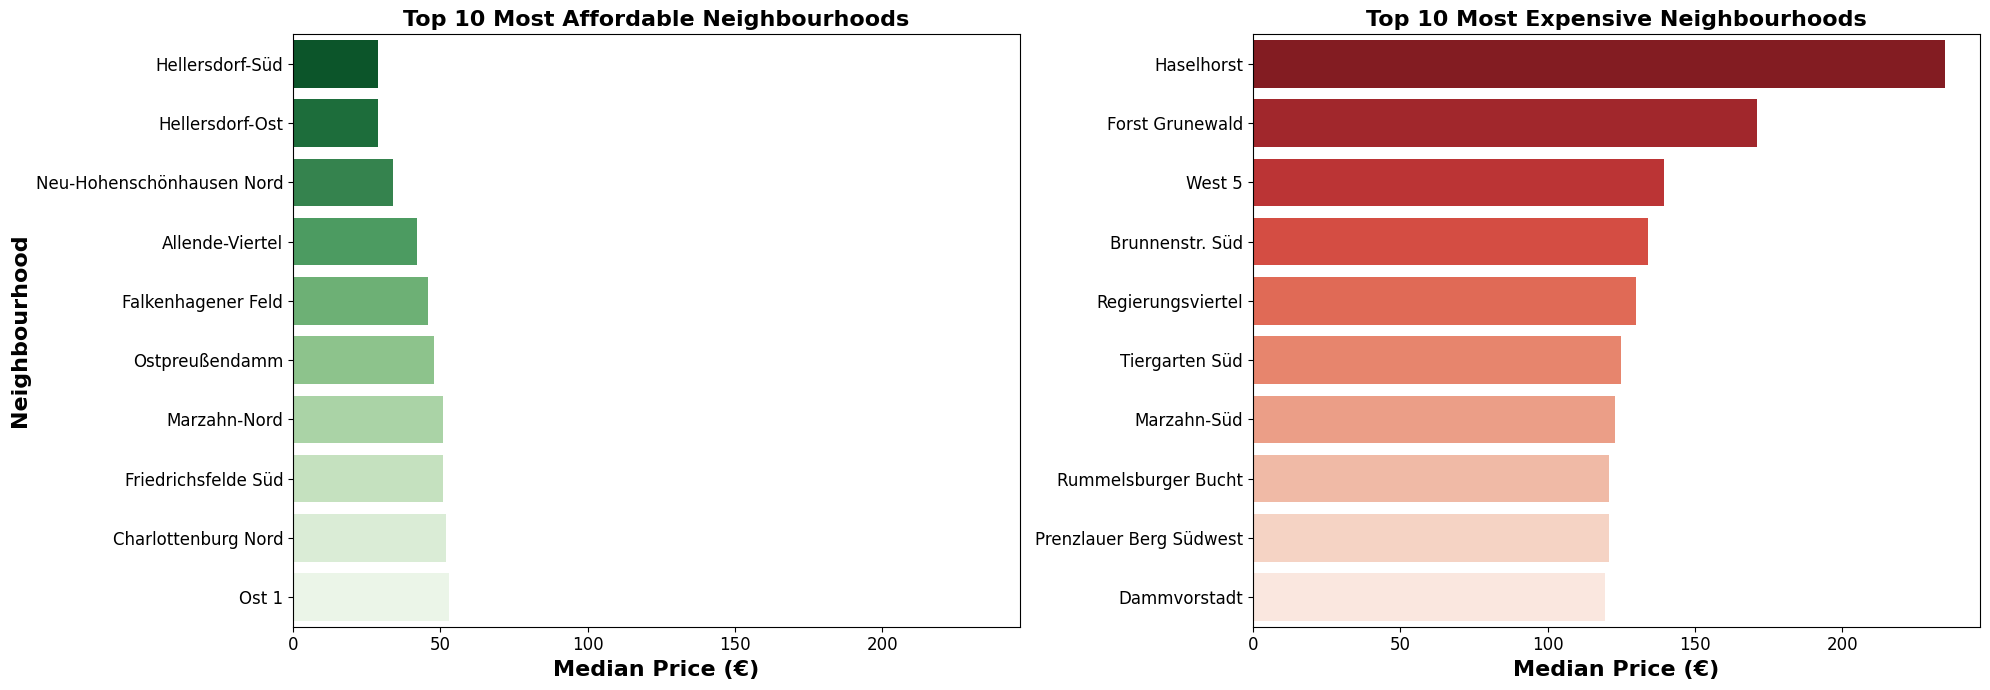

In [18]:
top10 = ind_neigh_prices.head(10)
bottom10 = ind_neigh_prices.tail(10).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharex=True, sharey=False)

sns.barplot(x=bottom10.values, y=bottom10.index, hue=bottom10.index, ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Most Affordable Neighbourhoods', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Median Price (€)', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Neighbourhood', fontsize=16, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=12)

sns.barplot(x=top10.values, y=top10.index, hue=top10.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 10 Most Expensive Neighbourhoods', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Median Price (€)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

The side-by-side bar plots shows a clear picture of price differences among individual Berlin neighbourhoods. **The most affordable areas, such as Hellersdorf-Süd, Hellersdorf-Ost, and Neu-Hohenschönhausen Nord, have median nightly prices well below €40. In contrast, neighbourhoods like Haselhorst and Forst Grunewald stand out as the most expensive, with median prices exceeding €150 and even going up to €200 per night.**

#### **Q5. What spatial patterns emerge when mapping listing prices across Berlin?**

By mapping both district-level median prices and individual Airbnb listings, we can reveal how accommodation costs are distributed across Berlin. This geographic perspective highlights price clusters, identifies high-demand zones, and surfaces affordability pockets—providing valuable insight for both strategic pricing and guest decision-making.

In [19]:
district_stats[['District', 'Median Price (€)']]

,District,Median Price (€)
0,Mitte,110.0
1,Friedrichshain-Kreuzberg,96.0
2,Pankow,95.0
3,Charlottenburg-Wilm.,91.0
4,Lichtenberg,86.5
5,Neukölln,85.0
6,Tempelhof - Schöneberg,85.0
7,Treptow - Köpenick,82.0
8,Steglitz - Zehlendorf,80.0
9,Spandau,78.0


In [ ]:
import folium
import geopandas as gpd
from folium.plugins import MarkerCluster
from folium.features import DivIcon

# Define price bins and colors for individual listing markers
bins = [0, 50, 100, 150, 250, 500, df_zoomed['price'].max()]
colors = ["#BFF977", "#C5E49B", "#F0EB5F", "#E8BE5D", "#F7911C", "#E71414"]

def get_color(price):
    for i, upper in enumerate(bins[1:]):
        if price <= upper:
            return colors[i]
    return colors[-1]

# Load GeoJSON for Berlin districts
district_geojson = '../data/berlin_bezirke.geojson' 
gdf = gpd.read_file(district_geojson)


# Build Folium map centered on Berlin
berlin_center = [df_zoomed['latitude'].mean(), df_zoomed['longitude'].mean()]
m = folium.Map(location=berlin_center, zoom_start=11, tiles='OpenStreetMap')

# Add choropleth of districts, colored by median price
folium.Choropleth(
    geo_data=district_geojson,
    name='Choropleth',
    data=district_stats,
    columns=['District', 'Median Price (€)'],
    key_on='feature.properties.name', 
    fill_color='YlOrRd',
    fill_opacity=0.5,
    line_opacity=0.7,
    legend_name='Median Nightly Prices by District (€)',
    highlight=True,
    nan_fill_color='lightgray'
).add_to(m)

# Add individual Airbnb listings as color-coded circles
marker_cluster = MarkerCluster().add_to(m)
for _, row in df_zoomed.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=10,
        fill=True,
        fill_color=get_color(row['price']),
        fill_opacity=0.6,
        color=None,
        weight=0,
        popup=(f"<b>Price:</b> €{row['price']:.0f}<br>"
               f"<b>Neighbourhood:</b> {row['neighbourhood_cleansed']}")
    ).add_to(marker_cluster)

# Add district names as labels at centroids (projected CRS for accuracy)
gdf_projected = gdf.to_crs(epsg=25833)
gdf['centroid'] = gdf_projected.centroid.to_crs(gdf.crs)

for idx, row in gdf.iterrows():
    centroid = row['centroid']
    folium.map.Marker(
        [centroid.y, centroid.x],
        icon=DivIcon(
            icon_size=(120, 15),
            icon_anchor=(0, 0),
            html=f'<div style="font-size: 12pt; color: black; font-weight: bold; text-shadow: 0px 0px 3px white;">{row["name"]}</div>',
        )
    ).add_to(m)

# Custom legend for listing price colors
legend_html = '''
 <div style="
     position: fixed; 
     bottom: 20px; left: 20px; width: 140px; height: 170px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color: white; padding: 10px;
 ">
 <b> Listing Prices (€)</b><br>
 <i style="background: #BFF977; width: 18px; height: 18px; float: left; margin-right: 8px; opacity:0.8;"></i> 0–50<br>
 <i style="background: #C5E49B; width: 18px; height: 18px; float: left; margin-right: 8px; opacity:0.8;"></i> 51–100<br>
 <i style="background: #F0EB5F; width: 18px; height: 18px; float: left; margin-right: 8px; opacity:0.8;"></i> 101–150<br>
 <i style="background: #E8BE5D; width: 18px; height: 18px; float: left; margin-right: 8px; opacity:0.8;"></i> 151–250<br>
 <i style="background: #F7911C; width: 18px; height: 18px; float: left; margin-right: 8px; opacity:0.8;"></i> 251–500<br>
 <i style="background: #E71414; width: 18px; height: 18px; float: left; margin-right: 8px; opacity:0.8;"></i> 500+<br>
 </div>
 '''

m.get_root().html.add_child(folium.Element(legend_html))
m

The interactive Folium map used in this analysis cannot be rendered directly on GitHub when viewing Jupyter notebooks. To ensure consistent visualization across platforms, I have included a static screenshot of the map below.

![Berlin Airbnb Map](../images/berlin_folium_map.png)

The map above displays Berlin’s districts shaded by median nightly Airbnb prices.

- **City Center Cluster:** **High prices and dense listings cluster in the city center.** Areas around central Berlin – including Mitte and adjacent neighbourhoods – show many listings (dense clusters of points on the map) often colored in warmer tones indicating higher prices. This aligns with the expectation that central, tourist-favored areas both have more Airbnbs and charge more.
- **Peripheral Areas:** **Outskirts of Berlin show sparser listing density (fewer listings, scattered points).** These are mostly colored with cooler tones, indicating lower prices. Districts far from the center (like the edges of Reinickendorf, Marzahn-Hellersdorf, etc.) have not only fewer Airbnbs but also predominantly cheaper listings.
- **Transitional Zones:** **Some mid-distance neighbourhoods (for example, parts of Pankow or Neukölln that are not in the immediate city center) have a mix of prices. They often serve as an intermediate option for travelers – not as pricey as the central Mitte, but more convenient than the far outskirts, with moderate listing density.**

From the spatial perspective, it is evident that **proximity to Berlin’s core correlates with both supply and price – central areas are the hotspot for Airbnb activity.** For Airbnb, this insight could inform targeted marketing or support in lesser-served districts, and for guests, it visualizes the trade-off between location and cost. Hosts can also identify how competitive their area is: a cluster of many nearby listings might mean they need to work harder to stand out (through pricing, amenities, etc.).

#### **Q6. Which districts show the highest supply and guest engagement (in terms of listings and reviews)?**

To pinpoint the most popular areas, we analyze which districts have the highest number of listings and the greatest total volume of guest reviews. This will help highlight where guest demand and host activity are most concentrated across the city.

In [21]:
# Calculate summary popularity stats as median price, listing count, total reviews, and average review score by district
popularity_stats = (
    df_zoomed.groupby('neighbourhood_group_cleansed')
    .agg(
        price = ('price', 'median'),
        listings_count=('neighbourhood_group_cleansed', 'count'),
        total_reviews=('number_of_reviews', 'sum'),
        review_score=('review_scores_rating', 'mean'))
        .reset_index()
        .rename(columns={'price': 'Median Price (€)',
                        'neighbourhood_group_cleansed': 'District',
                         'listings_count': 'Number of Listings',
                         'total_reviews': 'Total Reviews',
                         'review_score': 'Average Review Score'})
        .sort_values(by='Total Reviews', ascending=False)
        .reset_index(drop=True))

popularity_stats

,District,Median Price (€),Number of Listings,Total Reviews,Average Review Score
0,Mitte,110.0,1947,128780,4.761757
1,Friedrichshain-Kreuzberg,96.0,1820,125011,4.796093
2,Pankow,95.0,1311,90499,4.781800
3,Charlottenburg-Wilm.,91.0,1069,45001,4.750215
4,Neukölln,85.0,741,35324,4.779406
5,Tempelhof - Schöneberg,85.0,623,34654,4.769454
6,Treptow - Köpenick,82.0,427,15361,4.777611
7,Lichtenberg,86.5,262,13502,4.733168
8,Steglitz - Zehlendorf,80.0,262,8124,4.793664
9,Reinickendorf,62.0,137,7871,4.784015


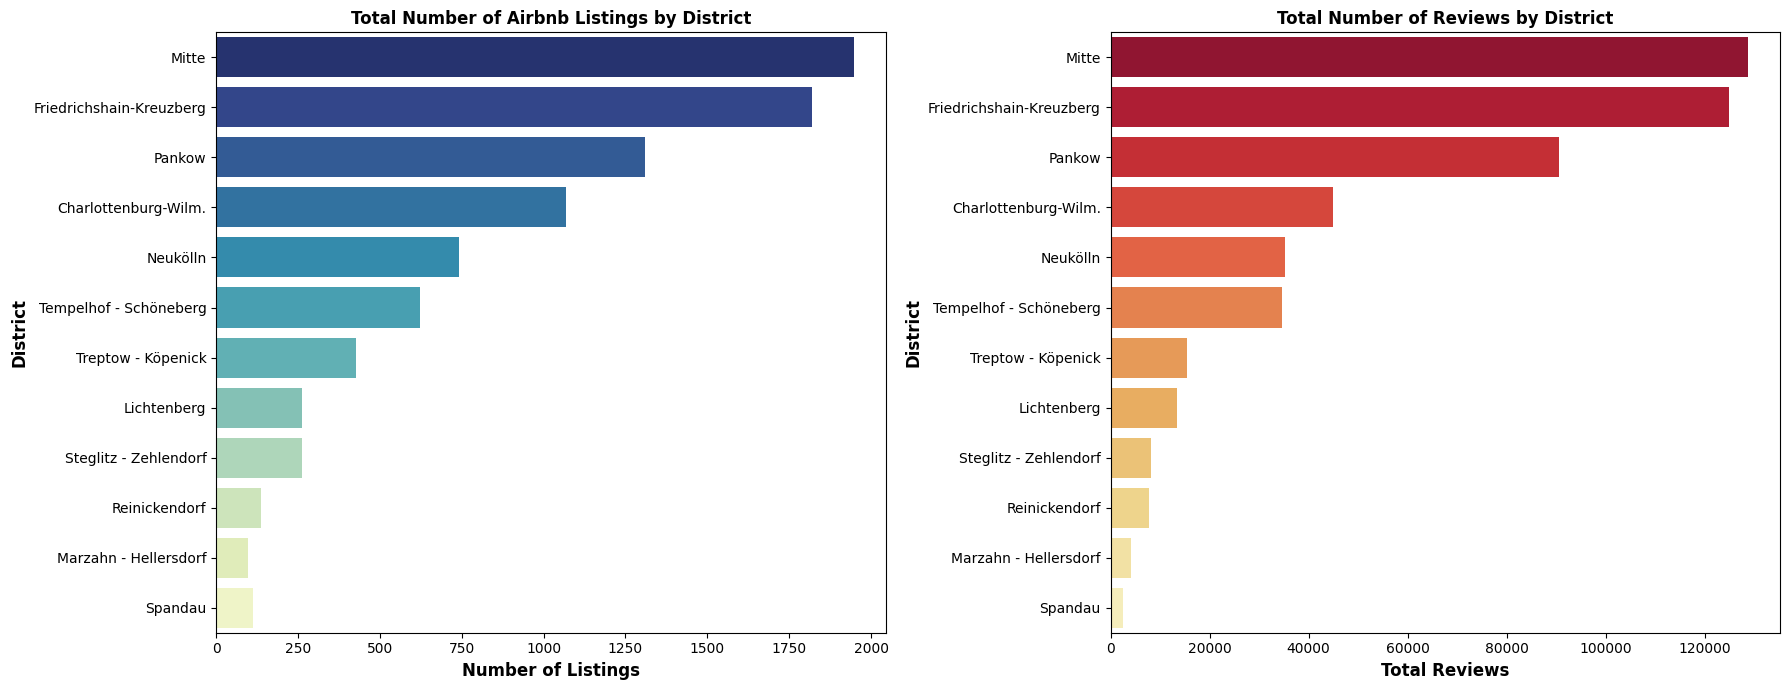

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Number of Listings', y='District', hue='District', data=popularity_stats, ax = ax[0], palette='YlGnBu_r')
ax[0].set_title('Total Number of Airbnb Listings by District', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Number of Listings', fontsize=12, fontweight='bold')
ax[0].set_ylabel('District', fontsize=12, fontweight='bold')

sns.barplot(x='Total Reviews', y='District', hue='District', data=popularity_stats, ax = ax[1], palette='YlOrRd_r')
ax[1].set_title('Total Number of Reviews by District', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Total Reviews', fontsize=12, fontweight='bold')
ax[1].set_ylabel('District', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
corr = popularity_stats[['Number of Listings', 'Total Reviews']].corr().iloc[0,1]
print(f"Correlation coefficient between number of listings and total reviews: {corr:.2f}")

Correlation coefficient between number of listings and total reviews: 0.98


**There is a very strong positive correlation: districts with more listings also tend to have more guest reviews, indicating that supply and demand are aligned.**

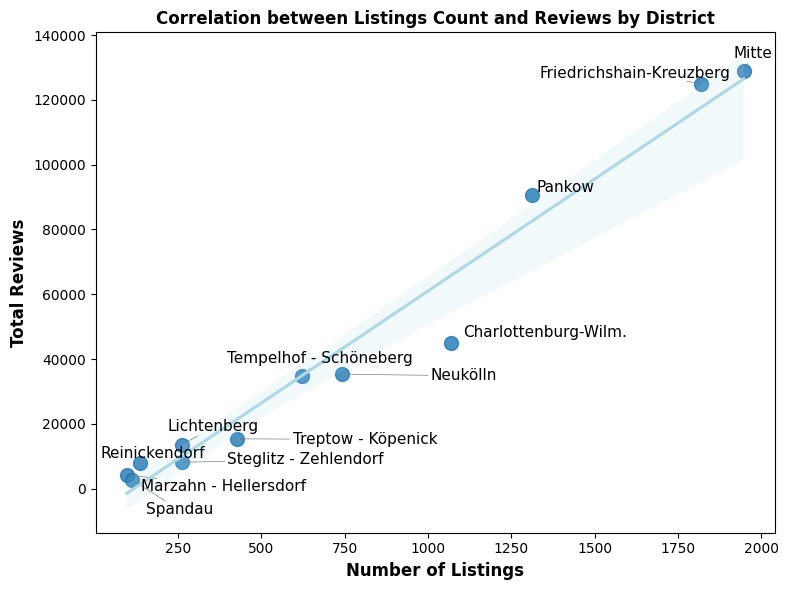

In [24]:
plt.figure(figsize=(8, 6))

sns.regplot(
    x='Number of Listings',
    y='Total Reviews',
    data=popularity_stats,
    scatter_kws={'s': 100},
    line_kws={'color': 'lightblue'}
)

texts = []
for i, row in popularity_stats.iterrows():
    texts.append(
        plt.text(
            row['Number of Listings'],
            row['Total Reviews'],
            row['District'],
            fontsize=11
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.title('Correlation between Listings Count and Reviews by District', fontsize=12, fontweight='bold')
plt.xlabel('Number of Listings', fontsize=12, fontweight='bold')
plt.ylabel('Total Reviews', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

- **Top Supply:** **Mitte has the greatest number of listings (almost 2,000), closely followed by Friedrichshain-Kreuzberg (around 1,820). Pankow also has a high count. These three districts alone account for a large share of Berlin’s Airbnb market.** In contrast, districts like Marzahn-Hellersdorf or Spandau have fewer than 100–200 listings each, reflecting much lower Airbnb penetration.
- **Guest Reviews:** **Total review count is a proxy for guest stays (more reviews generally means more bookings). Here again Mitte and Friedrichshain-Kreuzberg dominate heavy guest traffic. Pankow and Charlottenburg-Wilmersdorf also have high review totals, consistent with their strong supply and tourist appeal.** Outer districts not only have fewer listings but also far fewer reviews collectively – for example, Marzahn-Hellersdorf’s listings have relatively sparse review counts overall.

**The strong alignment between listings count and review totals suggests that being in a popular area boosts the chances of frequent bookings by guests.**

#### **Q7. Are there “hidden gem” or overpriced areas based on price vs. popularity/review scores?**

Identifying neighbourhoods that outperform or underperform their price, based on guest popularity and review scores, lets us spotlight high-value hidden gems in marketing and guide pricing support for less competitive areas. This supports data-driven recommendations for guests and helps hosts optimize both visibility and pricing.

In [25]:
popularity_stats

,District,Median Price (€),Number of Listings,Total Reviews,Average Review Score
0,Mitte,110.0,1947,128780,4.761757
1,Friedrichshain-Kreuzberg,96.0,1820,125011,4.796093
2,Pankow,95.0,1311,90499,4.781800
3,Charlottenburg-Wilm.,91.0,1069,45001,4.750215
4,Neukölln,85.0,741,35324,4.779406
5,Tempelhof - Schöneberg,85.0,623,34654,4.769454
6,Treptow - Köpenick,82.0,427,15361,4.777611
7,Lichtenberg,86.5,262,13502,4.733168
8,Steglitz - Zehlendorf,80.0,262,8124,4.793664
9,Reinickendorf,62.0,137,7871,4.784015


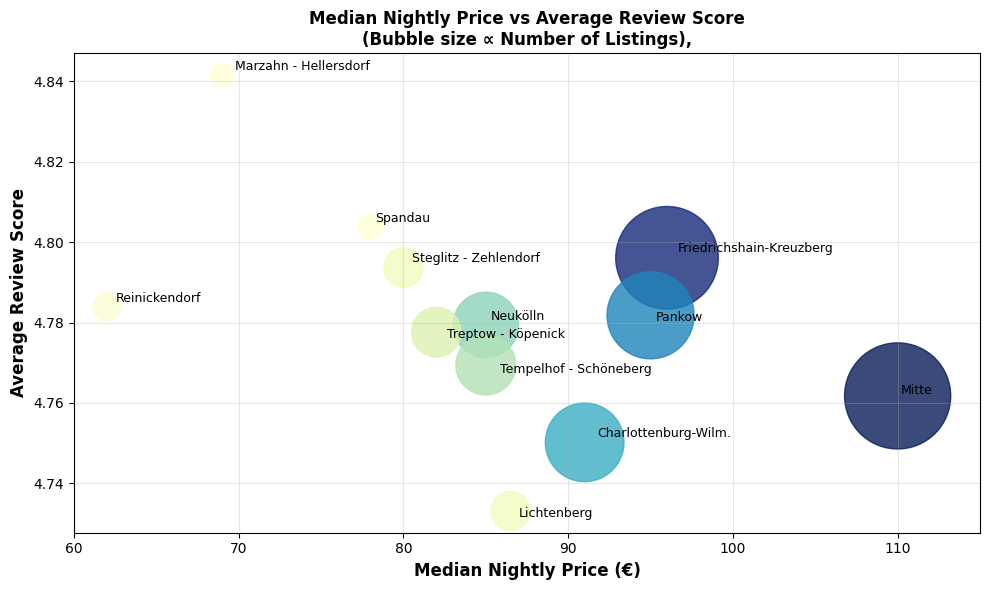

In [26]:
plt.figure(figsize=(10,6))

sc = plt.scatter(
    popularity_stats['Median Price (€)'],
    popularity_stats['Average Review Score'],
    s=popularity_stats['Number of Listings']*3,
    c=popularity_stats['Number of Listings'],
    cmap='YlGnBu',
    alpha=0.8
)

texts = []
for _, row in popularity_stats.iterrows():
    texts.append(
        plt.text(row['Median Price (€)'],
                 row['Average Review Score'],
                 row['District'],
                 fontsize=9)
    )
# automatically adjust to avoid overlap
adjust_text(texts, 
            only_move={'points':'y', 'texts':'y'},
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.6))

plt.title('Median Nightly Price vs Average Review Score\n'
    '(Bubble size ∝ Number of Listings)'',', fontsize=12, fontweight='bold')
plt.xlabel('Median Nightly Price (€)', fontsize=12, fontweight='bold')
plt.ylabel('Average Review Score', fontsize=12, fontweight='bold')
plt.xlim(60, 115)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

This bubble chart reveals key price-to-value relationships among Berlin’s districts.

- **Hidden gems (top left, e.g., Marzahn-Hellersdorf, Reinickendorf)**: These districts offer above-average review scores at below-average prices, suggesting strong guest satisfaction and potential for greater marketing emphasis. Airbnb could highlight these areas as value picks to guests or hosts toward modest price increases.
- **Premium but competitive (bottom right, e.g., Mitte, Charlottenburg-Wilmersdorf)**: Districts with the highest prices don’t necessarily have the highest guest ratings. This signals potential price sensitivity—Airbnb may recommend value-adding upgrades, dynamic pricing, or additional host support in these zones.
- **Balanced performers (center, e.g., Friedrichshain-Kreuzberg, Pankow)**: These districts balance healthy booking volumes, strong ratings, and solid pricing, reflecting robust, mature markets. Airbnb can maintain or fine-tune support in these key areas.
- **Bubble size (number of listings) signals market share:** **Larger bubbles, like Mitte and Friedrichshain-Kreuzberg, are vital markets**, therefore maintaining guest satisfaction here seems crucial.

#### **Q8. How do different room types (entire home, private, shared, hotel) compare in popularity, price, and availability?**

Comparing room types reveals which categories are most popular, command higher prices, or offer greater availability.

In [27]:
# Calculate summary room type stats, showing median price, number of listings, and average availability for each Airbnb room type
roomtype_stats = (
    df_zoomed.groupby('room_type')
      .agg(
          median_price=('price', 'median'),
          listings_count=('room_type', 'count'),
          average_availability=('availability_30', 'mean')
      )
      .reset_index()
      .rename(columns={
          'room_type': 'Room Type',
          'median_price': 'Median Price (€)',
          'listings_count': 'Number of Listings',
          'average_availability': 'Average Availability (30 days)'
      })
      .sort_values(by='Median Price (€)', ascending=False)
)

roomtype_stats

,Room Type,Median Price (€),Number of Listings,Average Availability (30 days)
1,Hotel room,123.5,78,21.435897
0,Entire home/apt,106.0,6502,13.036604
2,Private room,61.0,2158,16.437905
3,Shared room,25.0,71,22.140845


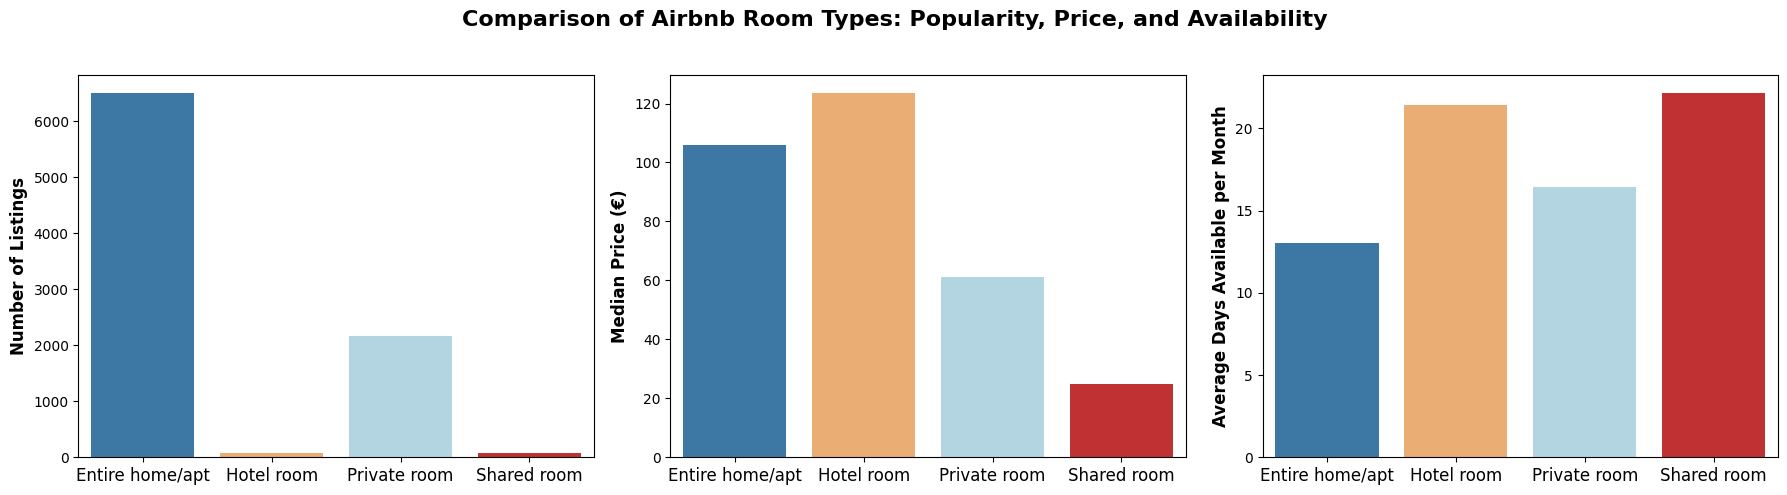

In [28]:
room_type_palette = {
    'Entire home/apt': '#2C7BB6',
    'Hotel room':      '#FDAE61',
    'Private room':    '#ABD9E9',
    'Shared room':     '#D7191C',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_order = list(room_type_palette.keys())

sns.barplot(x='Room Type', y='Number of Listings', hue='Room Type', data=roomtype_stats, ax=axes[0],
            order=plot_order, palette=room_type_palette)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Listings', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=12)

sns.barplot(x='Room Type', y='Median Price (€)', hue='Room Type', data=roomtype_stats, ax=axes[1],
            order=plot_order, palette=room_type_palette)
axes[1].set_xlabel('')
axes[1].set_ylabel('Median Price (€)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', labelsize=12)


sns.barplot(x='Room Type', y='Average Availability (30 days)', hue='Room Type', data=roomtype_stats, ax=axes[2],
            order=plot_order, palette=room_type_palette)
axes[2].set_xlabel('')
axes[2].set_ylabel('Average Days Available per Month', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', labelsize=12)

plt.suptitle('Comparison of Airbnb Room Types: Popularity, Price, and Availability', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Berlin offers several Airbnb room type options. Entire homes and hotel rooms target higher-budget travelers, while private and shared rooms provide budget-friendly alternatives and more frequent availability.

- **Entire home/apt dominates the Berlin market by number of listings**, followed by private rooms.
- **Hotel rooms have the highest median nightly price**, with entire homes/apartments also priced at similar range.
- **Shared rooms are the most affordable and tend to have the highest availability**, while entire homes/apartments are booked most often.

### **Q9. How do amenities impact price and booking popularity?**

Amenities play a critical role in shaping guest preferences and listing performance. By identifying which features are most commonly offered and also examining how the number of amenities relates to nightly prices and review volume, we can uncover what truly adds value to properties. This insight helps hosts prioritize meaningful upgrades and enables Airbnb to improve recommendation systems and guest satisfaction.

Let's explore the relationship between amenity count, median price, and guest engagement (via number of reviews) to assess their impact on demand and revenue potential:

In [29]:
# Convert string representations of lists in 'amenities_list' column to actual Python lists
import ast

df_zoomed['amenities_list'] = df_zoomed['amenities_list'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_zoomed['amenities_list']

0       [bathtub, dishes and silverware, bed linens, p...
1       [bathtub, dryer, dishes and silverware, bed li...
2       [heating, host greets you, smoke alarm, coffee...
3       [heating, room-darkening shades, children\u201...
4       [dishes and silverware, luggage dropoff allowe...
                              ...                        
8893       [kitchen, pets allowed, tv, wifi, smoke alarm]
8894    [kitchen, pets allowed, tv, washer, wifi, smok...
8895         [kitchen, washer, wifi, dedicated workspace]
8896    [shower gel, dishes and silverware, backyard -...
8897    [kitchenette, dishes and silverware, bed linen...
Name: amenities_list, Length: 8809, dtype: object

In [30]:
from itertools import chain

# Flatten all amenities into a single list
all_amenities = list(chain.from_iterable(df_zoomed['amenities_list']))

# Count their frequency
amenity_counts = pd.Series(all_amenities).value_counts()

In [31]:
amenity_counts

kitchen                          7920
wifi                             7910
smoke alarm                      7609
hot water                        7053
hair dryer                       6806
                                 ... 
beko  refrigerator                  1
fast wifi \u2013 210 mbps           1
fast wifi \u2013 69 mbps            1
ub box bluetooth sound system       1
cocacola refrigerator               1
Name: count, Length: 2160, dtype: int64

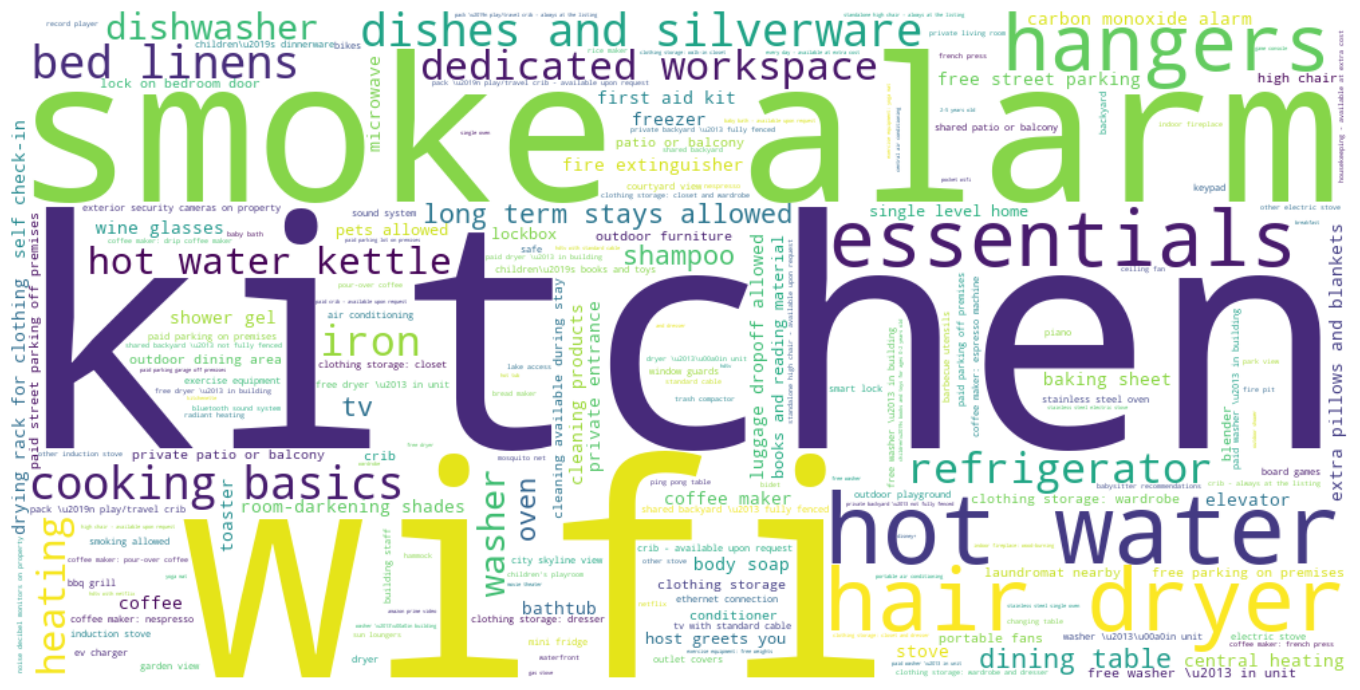

In [32]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(amenity_counts)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.tight_layout()
plt.show()

The word cloud above highlights the most frequently offered amenities in Berlin’s Airbnb listings. **Core essentials, such as kitchen, Wi-Fi, smoke alarm, and hot water, dominate, reflecting baseline guest expectations. Other common features include refrigerators, hair dryers, and dishwashers, suggesting a valuable emphasis on comfort and self-sufficiency.**

Now explore how the quantity of amenities correlates with listing performance in terms of median nightly price and guest engagement: 

In [33]:
df_zoomed['amenities_count'].max()

88

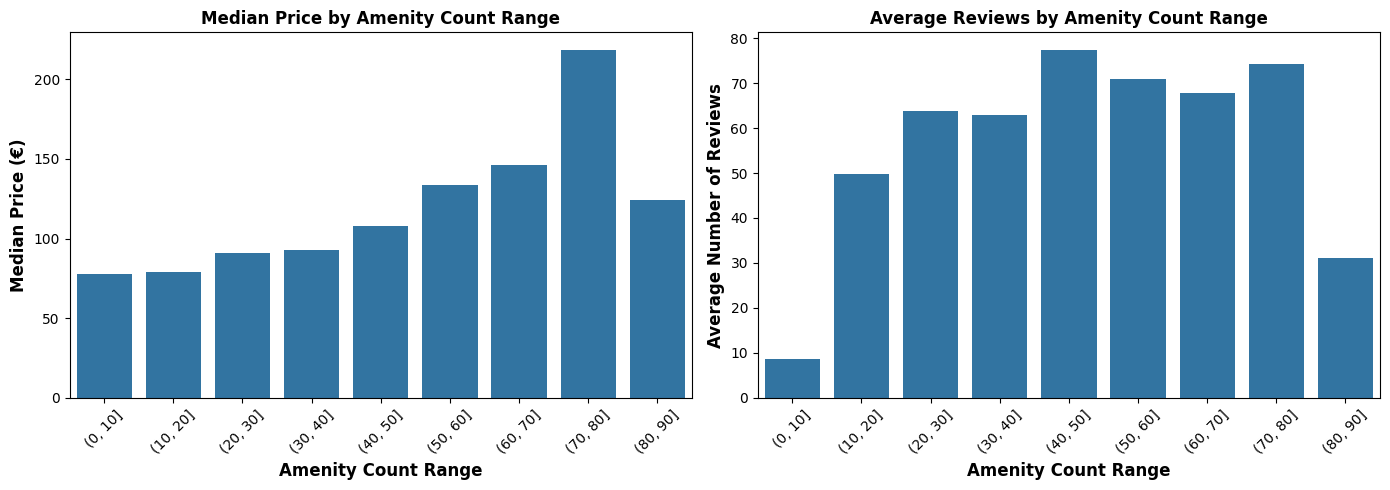

In [34]:
# Create amenity bins (0–10, 10–20, ...)
df_zoomed['amenity_bin'] = pd.cut(df_zoomed['amenities_count'], bins=range(0, 100, 10))

# Group by bins and plot
amenities_grouped = df_zoomed.groupby('amenity_bin', observed=True).agg({
    'price': 'median',
    'number_of_reviews': 'mean'
}).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='amenity_bin', y='price', data=amenities_grouped, ax=ax[0])
ax[0].set_title("Median Price by Amenity Count Range", fontsize=12, fontweight='bold')
ax[0].set_ylabel("Median Price (€)", fontsize=12, fontweight='bold')

sns.barplot(x='amenity_bin', y='number_of_reviews', data=amenities_grouped, ax=ax[1])
ax[1].set_title("Average Reviews by Amenity Count Range", fontsize=12, fontweight='bold')
ax[1].set_ylabel("Average Number of Reviews", fontsize=12, fontweight='bold')

for a in ax:
    a.set_xlabel("Amenity Count Range", fontsize=12, fontweight='bold')
    a.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Offering more amenities is generally associated with higher pricing power and guest engagement.**

Based on the analyses above, **hosts should prioritize essential amenities and consider adding popular extras to enhance guest appeal and boost earnings. For Airbnb, highlighting high-impact amenities in search filters can better align listings with guest preferences and help justify price differences.**

#### **Q10. Do superhosts and regular hosts achieve higher prices or occupancy?**

Comparing superhosts to regular hosts reveals if recognition and tenure lead to higher prices or booking rates. This helps Airbnb refine host programs and guide guest choices for reliability and value.

In [35]:
# Group by superhost status and calculate summary superhost stats
superhost_stats = (
    df_zoomed.groupby('host_is_superhost')
      .agg(
          listings_count=('price', 'count'),
          mean_price=('price', 'mean'),
          median_price=('price', 'median')
      )
      .reset_index()
      .rename(columns={'host_is_superhost': 'Superhost',
                       'listings_count': 'Number of Listings',
                       'mean_price': 'Average Price (€)',
                       'median_price': 'Median Price (€)'})
)

superhost_stats['Superhost'] = superhost_stats['Superhost'].replace({'t': 'Superhost', 'f': 'Regular Host'})

superhost_stats

,Superhost,Number of Listings,Average Price (€),Median Price (€)
0,Regular Host,5993,109.397797,92.0
1,Superhost,2816,117.975142,95.0


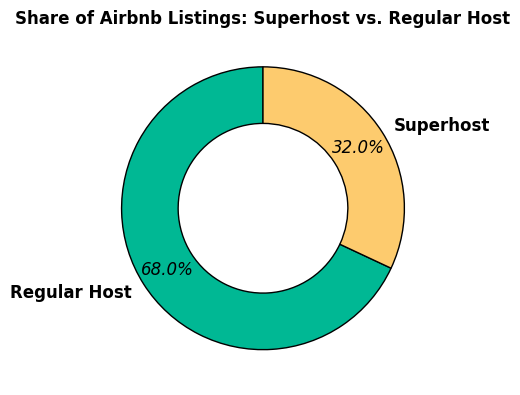

In [36]:
labels = superhost_stats['Superhost']
sizes = superhost_stats['Number of Listings']

colors = ['#00b894', '#fdcb6e']

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width': 0.4, 'edgecolor': 'black'},
    pctdistance=0.80,
)
plt.setp(autotexts, size=12, style='italic')
plt.setp(texts, size=12, weight="bold")

plt.title('Share of Airbnb Listings: Superhost vs. Regular Host', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

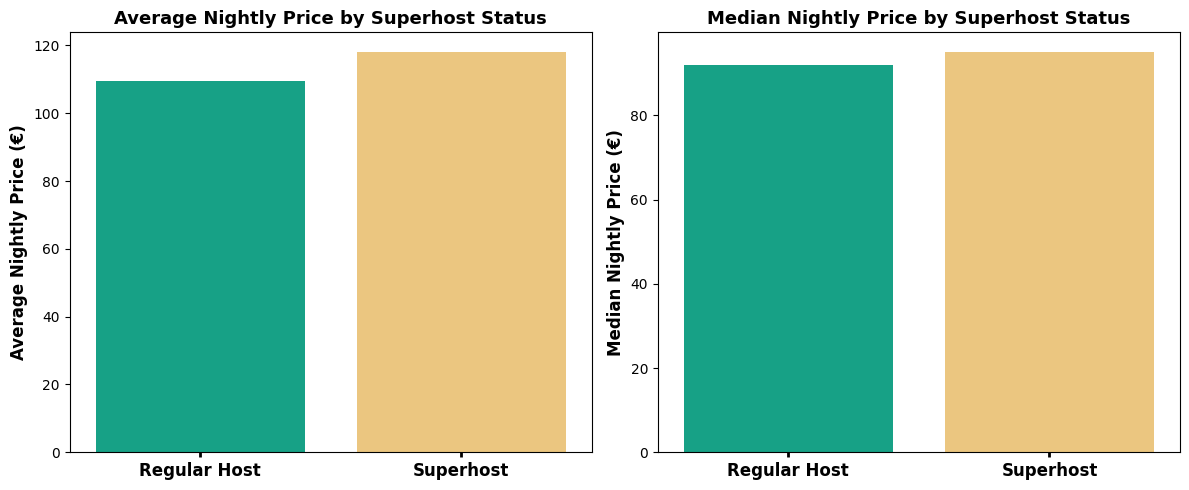

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#00b894', '#fdcb6e']

# Average price by superhost status
sns.barplot(
    x='Superhost',
    y='Average Price (€)',
    hue='Superhost',
    data=superhost_stats,
    ax=ax[0],
    palette=colors
)
ax[0].set_title('Average Nightly Price by Superhost Status', fontsize=13, fontweight='bold')
ax[0].set_ylabel('Average Nightly Price (€)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('', fontsize=12)
ax[0].tick_params(axis='x', labelsize=12, labelcolor='black', width=2)
for label in ax[0].get_xticklabels():
    label.set_fontweight('bold')

# Median price by superhost status
sns.barplot(
    x='Superhost',
    y='Median Price (€)',
    hue='Superhost',
    data=superhost_stats,
    ax=ax[1],
    palette=colors
)
ax[1].set_title('Median Nightly Price by Superhost Status', fontsize=13, fontweight='bold')
ax[1].set_ylabel('Median Nightly Price (€)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('', fontsize=12)
ax[1].tick_params(axis='x', labelsize=12, labelcolor='black', width=2)
for label in ax[1].get_xticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

**Superhosts account for about one-third of Berlin Airbnb listings, but they do not necessarily charge a lot more than those of regular hosts. This suggests that while superhost status may signal trust or reliability, it does not lead to a substantial price premium in the Berlin market.**

#### **Q11. What are the key relationships among core listing features (price, reviews, availability, etc.)?**

Understanding how price, reviews, availability, amenities, and host experience interact provides valuable insights for hosts and the Airbnb platform. Analyzing these correlations helps to refine pricing guidance, surface the most relevant listings to guests, and support hosts in optimizing their offering.


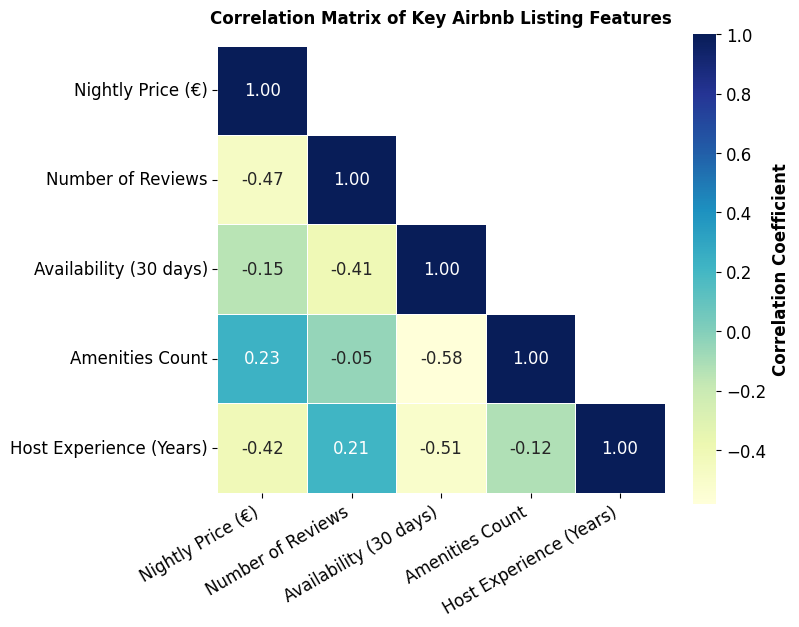

In [38]:
corr_df = df_zoomed[['price', 'number_of_reviews', 'availability_30', 'amenities_count', 'host_experience_years']].corr()

# Map labels as before
label_map = {
    'price': 'Nightly Price (€)',
    'number_of_reviews': 'Number of Reviews',
    'review_scores_rating': 'Review Rating',
    'availability_30': 'Availability (30 days)',
    'amenities_count': 'Amenities Count',
    'host_experience_years': 'Host Experience (Years)'
}

corr_renamed = corr_df.rename(columns=label_map).rename(index=label_map)
corr_matrix = corr_renamed.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # k=1 means do not mask the diagonal


plt.figure(figsize=(8, 7))
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    mask=mask,
    cmap='YlGnBu',
    fmt=".2f",
    linewidths=0.7,
    square=True,
    annot_kws={'size':12},
    cbar_kws={'label': 'Correlation Coefficient', 'shrink': 0.85}
)

plt.xticks(fontsize=12, rotation=30, ha='right')
plt.yticks(fontsize=12,  rotation=0)
plt.title("Correlation Matrix of Key Airbnb Listing Features", fontsize=12, fontweight='bold', pad=16)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12) 
cbar.set_label('Correlation Coefficient', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

- Nightly price correlates moderately negatively with both number of reviews (r = −0.47) and host experience (r = −0.42). **Listings with more reviews or run by experienced hosts tend to be priced more competitively, while higher-priced listings often have fewer reviews and are managed by less experienced hosts.**
- Availability over 30 days shows a moderate negative correlation with amenities count (r = −0.58), host experience (r = −0.51), and number of reviews (r = −0.41). This suggests that **well-equipped, highly reviewed listings—especially those run by experienced hosts—are in demand and therefore have fewer open nights.**
- There is a weak positive correlation between price and amenities count (r = +0.23), indicating **a small premium on nightly rates for listings that offer more features.**

**All of these correlations are in the low-to-moderate range, so while they point toward sensible patterns (e.g., “popular = booked up” or “more features = slightly higher price”), they are not strong enough alone to establish causality and draw definitive conclusions.**

### **4- Summary**
---
* **Berlin’s Airbnb Pricing is Skewed:** The typical listing costs around €94 per night (median), with most listings between €50 and €150. However, a few ultra-expensive listings (above €500) skew the average higher (€129). These outliers are rare – the market is largely mid-range, with plenty of affordable options and a smaller luxury segment.
* **Location Matters:** Central districts (like Mitte, Friedrichshain-Kreuzberg, Prenzlauer Berg in Pankow) are significantly more expensive and host the majority of listings. In contrast, outer districts (like Reinickendorf, Marzahn-Hellersdorf, Spandau) are more affordable, albeit with far fewer listings. For example, Mitte’s median price (€110) nearly doubles that of Reinickendorf (€60). This reflects higher demand and tourist appeal in the center.
* **Neighbourhood Variability:** Within districts, there are hot and fancy neighbourhoods and quieter ones. Some neighbourhoods in cheaper districts have unusually high prices (e.g. Haselhorst in Spandau, with median >€150), and some in expensive districts remain relatively cheap. The cheapest neighbourhoods in the city (e.g. parts of Hellersdorf) have median prices below €40, whereas the priciest neighbourhoods (e.g. Forst Grunewald, Haselhorst) exceed €150. This granularity is important for fine-tuned pricing and location strategy.
* **Geospatial Distribution:** Mapping the data showed a clear urban core vs. periphery divide. High-price, high-density clusters are centered in inner Berlin, while low-price, sparse listings are on the outskirts. This indicates that travelers strongly gravitate towards central locations, and there is less Airbnb coverage (and demand) in distant residential areas.
* **Demand and Popularity:** Mitte and surrounding areas are the most popular. They not only have the most listings but also the highest total number of reviews (guest stays). Outer districts see much less Airbnb traffic. Listings in tourist hubs accumulate many reviews and tend to have lower availability (more booked), whereas those in outlying areas often have their calendars more open.
* **Hidden Gems vs. Overpricing:** The analysis of price vs. popularity revealed that some lower-priced areas punch above their weight in attracting guests (hidden gems offering high value), while a few high-priced locales see surprisingly low booking numbers (potentially overpriced relative to their location/offerings). In general, lower prices correlate with more bookings – a consideration for hosts when setting prices, and for guests when hunting for value.
* **Room Type Differences:** Entire homes/apartments dominate Berlin’s Airbnb market and can charge the highest rates, yet they also enjoy strong demand (often booked solid). Private rooms are cheaper and somewhat less in demand, catering to budget travelers. Shared rooms are very inexpensive but represent a tiny niche with the lowest demand. This indicates most travelers prefer entire places, even at a premium, for the privacy and convenience.
* **Amenities Boost Price and Booking Rate:** Listings offering a wealth of amenities (from basics like kitchens and Wi-Fi to luxuries like balconies or wine glasses) tend to charge higher nightly prices and achieve higher occupancy. Well-equipped listings can earn more and are more competitive in attracting guests.
* **Superhost Advantage:** Superhosts in Berlin do not dramatically overcharge compared to other hosts, but their listings perform better. This suggests the Superhost badge is a reliable indicator of quality that translates into guest trust and bookings, rather than a justification for higher prices.
* **Interconnected Factors:** Some core factors of the Airbnb market show meaningful interplay. Notably, price and demand are inversely related (high prices limit the number of bookings, while competitive pricing can drive volume). Experienced hosts and amenity-rich listings succeed in keeping occupancy high, highlighting the value of hospitality experience and property investment. Meanwhile, nearly all active listings have high ratings, so competition is more about price, location, and amenities than about star rating.

### **5- Conclusion & Recommendations**
---
Berlin’s Airbnb market exhibits clear trends: **central areas and entire-home listings command a premium and enjoy the highest demand, while budget-friendly options exist in less central locations and smaller room types. Amenities and host quality significantly enhance a listing’s success. For hosts, the findings underscore the importance of competitive pricing (especially for new hosts or those outside prime locations), investing in amenities and guest experience, and the benefits of achieving superhost status.** 

**For guests, the analysis highlights that if location is flexible, great deals can be found outside the main tourist zones, and that many mid-range listings offer excellent value given the high overall ratings. For Airbnb, these insights can guide platform improvements, such as refined search filters (by neighbourhood, amenities) and dynamic pricing recommendations to balance the supply-demand mismatch in certain areas.** 

**Overall, the EDA provides a data-driven foundation for decision-making to optimize the Airbnb experience for all parties in Berlin.**